# Aspect Probability Estimation from Airbnb Reviews using Gemma3 and Ollama

This notebook estimates the probability (0-1) that specific aspects are mentioned in Airbnb reviews using the Gemma3 model via Ollama API.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import time
from tqdm import tqdm
import re
import warnings
warnings.filterwarnings('ignore')

# Set Ollama API endpoint
OLLAMA_API_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "gemma3"

# Define the aspects to evaluate
ASPECTS = [
    "Le logement",
    "Le lit",
    "La salle de bain",
    "La décoration",
    "L'espace",
    "La vue",
    "Les alentours",
    "L'accès aux transports et commerce",
    "Le quartier"
]

print(f"Ollama API endpoint: {OLLAMA_API_URL}")
print(f"Model: {MODEL_NAME}")
print(f"Aspects to evaluate: {len(ASPECTS)}")
for i, aspect in enumerate(ASPECTS, 1):
    print(f"  {i}. {aspect}")

Ollama API endpoint: http://localhost:11434/api/generate
Model: gemma3
Aspects to evaluate: 9
  1. Le logement
  2. Le lit
  3. La salle de bain
  4. La décoration
  5. L'espace
  6. La vue
  7. Les alentours
  8. L'accès aux transports et commerce
  9. Le quartier


## 2. Check Ollama Connection

In [2]:
# Test Ollama connection
def test_ollama_connection():
    try:
        payload = {
            "model": MODEL_NAME,
            "prompt": "Say hello",
            "stream": False
        }
        response = requests.post(OLLAMA_API_URL, json=payload, timeout=10)
        if response.status_code == 200:
            print("✓ Ollama connection successful!")
            result = response.json()
            print(f"Response: {result.get('response', '')[:100]}")
            return True
        else:
            print(f"✗ Ollama connection failed: Status {response.status_code}")
            return False
    except Exception as e:
        print(f"✗ Error connecting to Ollama: {str(e)}")
        print("Make sure Ollama is running: ollama serve")
        return False

# Test connection
test_ollama_connection()

✓ Ollama connection successful!
Response: Hello there! 😊 How’s your day going so far?


True

## 3. Load Reviews Data

In [6]:
# Load the same reviews data
reviews_df = pd.read_csv('./data/reviews_select.csv', nrows=50)

# Clean the data
reviews_df = reviews_df.dropna(subset=['comments'])
reviews_df['comments'] = reviews_df['comments'].astype(str)
reviews_df = reviews_df[reviews_df['comments'].str.strip() != '']
reviews_df = reviews_df.drop_duplicates(subset=['comments'])

print(f"Dataset shape: {reviews_df.shape}")
print(f"\nSample reviews:")
print(reviews_df['comments'].head(3).values)

Dataset shape: (50, 10)

Sample reviews:
['Alloggio confortevole e pratico, dotato di tutto quello che serve. Nonostante sia situato in centro è molto silenzioso.'
 'Très bon emplacement pour cet appartement typique au cœur d une belle vie de quartier  tout en se préservant du calme. Hyper central pour visiter la capitale'
 'What a wonderful gem.  Great location, it was spotless and the studio was recently renovated. Even a new sofa bed.  We thoroughly enjoyed our stay and highly recommend.']


## 4. Define Aspect Probability Function

In [7]:
def estimate_aspect_probabilities(text, aspects, max_retries=3):
    """
    Estimate the probability (0-1) that each aspect is mentioned in the text
    
    Args:
        text: The review text
        aspects: List of aspects to evaluate
        max_retries: Number of retries if the request fails
        
    Returns:
        Dictionary with aspect names as keys and probabilities as values
    """
    # Truncate text to reasonable length
    text = text[:1000]
    
    # Create aspects list as numbered string
    aspects_list_str = "\n".join([f"{i+1}. {aspect}" for i, aspect in enumerate(aspects)])
    
    prompt = f"""Pour le texte suivant, indique par une probabilité de 0 à 1 (où 0 = pas du tout mentionné, 1 = très clairement mentionné) si les aspects suivants sont mentionnés.

Aspects à évaluer:
{aspects_list_str}

Texte: "{text}"

Réponds UNIQUEMENT avec le format suivant (une ligne par aspect, format "numéro: valeur"):
1: 0.85
2: 0.30
etc.

Réponse:"""
    
    for attempt in range(max_retries):
        try:
            payload = {
                "model": MODEL_NAME,
                "prompt": prompt,
                "stream": False,
                "temperature": 0.2,
                "top_p": 0.9
            }
            
            response = requests.post(OLLAMA_API_URL, json=payload, timeout=30)
            
            if response.status_code == 200:
                result = response.json()
                response_text = result.get('response', '').strip()
                
                # Parse the response into probabilities
                probabilities = {}
                lines = response_text.split('\n')
                
                for i, aspect in enumerate(aspects, 1):
                    probabilities[aspect] = 0.0  # Default value
                
                for line in lines:
                    line = line.strip()
                    if ':' in line:
                        try:
                            parts = line.split(':')
                            if len(parts) == 2:
                                idx = int(parts[0].strip())
                                prob = float(parts[1].strip())
                                # Clamp probability between 0 and 1
                                prob = max(0.0, min(1.0, prob))
                                if 1 <= idx <= len(aspects):
                                    probabilities[aspects[idx-1]] = prob
                        except (ValueError, IndexError):
                            continue
                
                return probabilities
            else:
                if attempt < max_retries - 1:
                    time.sleep(2)
                    continue
                else:
                    return {aspect: 0.0 for aspect in aspects}
                    
        except requests.exceptions.Timeout:
            if attempt < max_retries - 1:
                time.sleep(2)
                continue
            else:
                return {aspect: 0.0 for aspect in aspects}
        except Exception as e:
            print(f"Error: {str(e)}")
            return {aspect: 0.0 for aspect in aspects}
    
    return {aspect: 0.0 for aspect in aspects}

# Test the function with a sample review
print("Testing aspect probability estimation...")
sample_review = reviews_df['comments'].iloc[0]
print(f"Sample review: {sample_review[:200]}...")
probabilities = estimate_aspect_probabilities(sample_review, ASPECTS)
print(f"\nExtracted probabilities:")
for aspect, prob in probabilities.items():
    print(f"  {aspect:40} {prob:.2f}")

Testing aspect probability estimation...
Sample review: Alloggio confortevole e pratico, dotato di tutto quello che serve. Nonostante sia situato in centro è molto silenzioso....

Extracted probabilities:
  Le logement                              0.75
  Le lit                                   0.60
  La salle de bain                         0.40
  La décoration                            0.20
  L'espace                                 0.50
  La vue                                   0.10
  Les alentours                            0.05
  L'accès aux transports et commerce       0.30
  Le quartier                              0.60


## 5. Estimate Probabilities for All Reviews

In [8]:
# Estimate probabilities for all reviews
print("Estimating aspect probabilities for all reviews...")
print("This may take a while depending on the number of reviews...\n")

all_probabilities = []
reviews_list = reviews_df['comments'].tolist()

for i, review in enumerate(tqdm(reviews_list, desc="Processing reviews")):
    probs = estimate_aspect_probabilities(review, ASPECTS)
    all_probabilities.append(probs)
    
    # Add a small delay to avoid overwhelming the API
    if (i + 1) % 5 == 0:
        time.sleep(1)

# Convert list of dictionaries to dataframe
probabilities_df = pd.DataFrame(all_probabilities)

# Add original reviews and probabilities to main dataframe
reviews_df = reviews_df.reset_index(drop=True)
for aspect in ASPECTS:
    reviews_df[f"prob_{aspect}"] = probabilities_df[aspect]

print(f"\nProbability estimation completed!")
print(f"\nSample results (first 5 reviews, first 3 aspects):")
cols_to_display = ['comments'] + [f"prob_{ASPECTS[i]}" for i in range(3)]
print(reviews_df[cols_to_display].head())

Estimating aspect probabilities for all reviews...
This may take a while depending on the number of reviews...



Processing reviews: 100%|██████████| 50/50 [09:13<00:00, 11.07s/it]


Probability estimation completed!

Sample results (first 5 reviews, first 3 aspects):
                                            comments  prob_Le logement  \
0  Alloggio confortevole e pratico, dotato di tut...              0.75   
1  Très bon emplacement pour cet appartement typi...              0.90   
2  What a wonderful gem.  Great location, it was ...              0.75   
3  We had a lovely 3 night stay.  Everything was ...              0.75   
4  Great location. Very calm and quiet. Small but...              0.75   

   prob_Le lit  prob_La salle de bain  
0          0.6                   0.40  
1          0.4                   0.20  
2          0.6                   0.25  
3          0.4                   0.60  
4          0.6                   0.80  


## 6. Analyze Probabilities

In [9]:
# Analyze probabilities
print("="*70)
print("ASPECT PROBABILITY ANALYSIS")
print("="*70)

print(f"\nTotal reviews analyzed: {len(reviews_df)}")

# Calculate statistics for each aspect
stats_list = []
for aspect in ASPECTS:
    col_name = f"prob_{aspect}"
    probs = reviews_df[col_name]
    
    stats = {
        'Aspect': aspect,
        'Mean_Probability': probs.mean(),
        'Std_Dev': probs.std(),
        'Min': probs.min(),
        'Max': probs.max(),
        'Median': probs.median(),
        'Mentioned_Threshold_0.5': (probs >= 0.5).sum(),
        'Percentage_Mentioned': (probs >= 0.5).sum() / len(reviews_df) * 100
    }
    stats_list.append(stats)

stats_df = pd.DataFrame(stats_list)
stats_df = stats_df.sort_values('Mean_Probability', ascending=False)

print("\n" + "-"*70)
print("Aspect Probability Statistics (sorted by average probability):")
print("-"*70)
for _, row in stats_df.iterrows():
    print(f"\n{row['Aspect']}:")
    print(f"  Mean probability:      {row['Mean_Probability']:.3f}")
    print(f"  Std deviation:         {row['Std_Dev']:.3f}")
    print(f"  Range:                 {row['Min']:.3f} - {row['Max']:.3f}")
    print(f"  Median:                {row['Median']:.3f}")
    print(f"  Mentioned (≥0.5):      {row['Mentioned_Threshold_0.5']:.0f} ({row['Percentage_Mentioned']:.1f}%)")

ASPECT PROBABILITY ANALYSIS

Total reviews analyzed: 50

----------------------------------------------------------------------
Aspect Probability Statistics (sorted by average probability):
----------------------------------------------------------------------

Le logement:
  Mean probability:      0.725
  Std deviation:         0.122
  Range:                 0.100 - 0.900
  Median:                0.750
  Mentioned (≥0.5):      49 (98.0%)

L'accès aux transports et commerce:
  Mean probability:      0.541
  Std deviation:         0.296
  Range:                 0.050 - 0.900
  Median:                0.625
  Mentioned (≥0.5):      32 (64.0%)

Le lit:
  Mean probability:      0.513
  Std deviation:         0.195
  Range:                 0.100 - 0.900
  Median:                0.600
  Mentioned (≥0.5):      31 (62.0%)

L'espace:
  Mean probability:      0.465
  Std deviation:         0.187
  Range:                 0.050 - 0.950
  Median:                0.500
  Mentioned (≥0.5):      32 (64

## 7. Visualize Probabilities

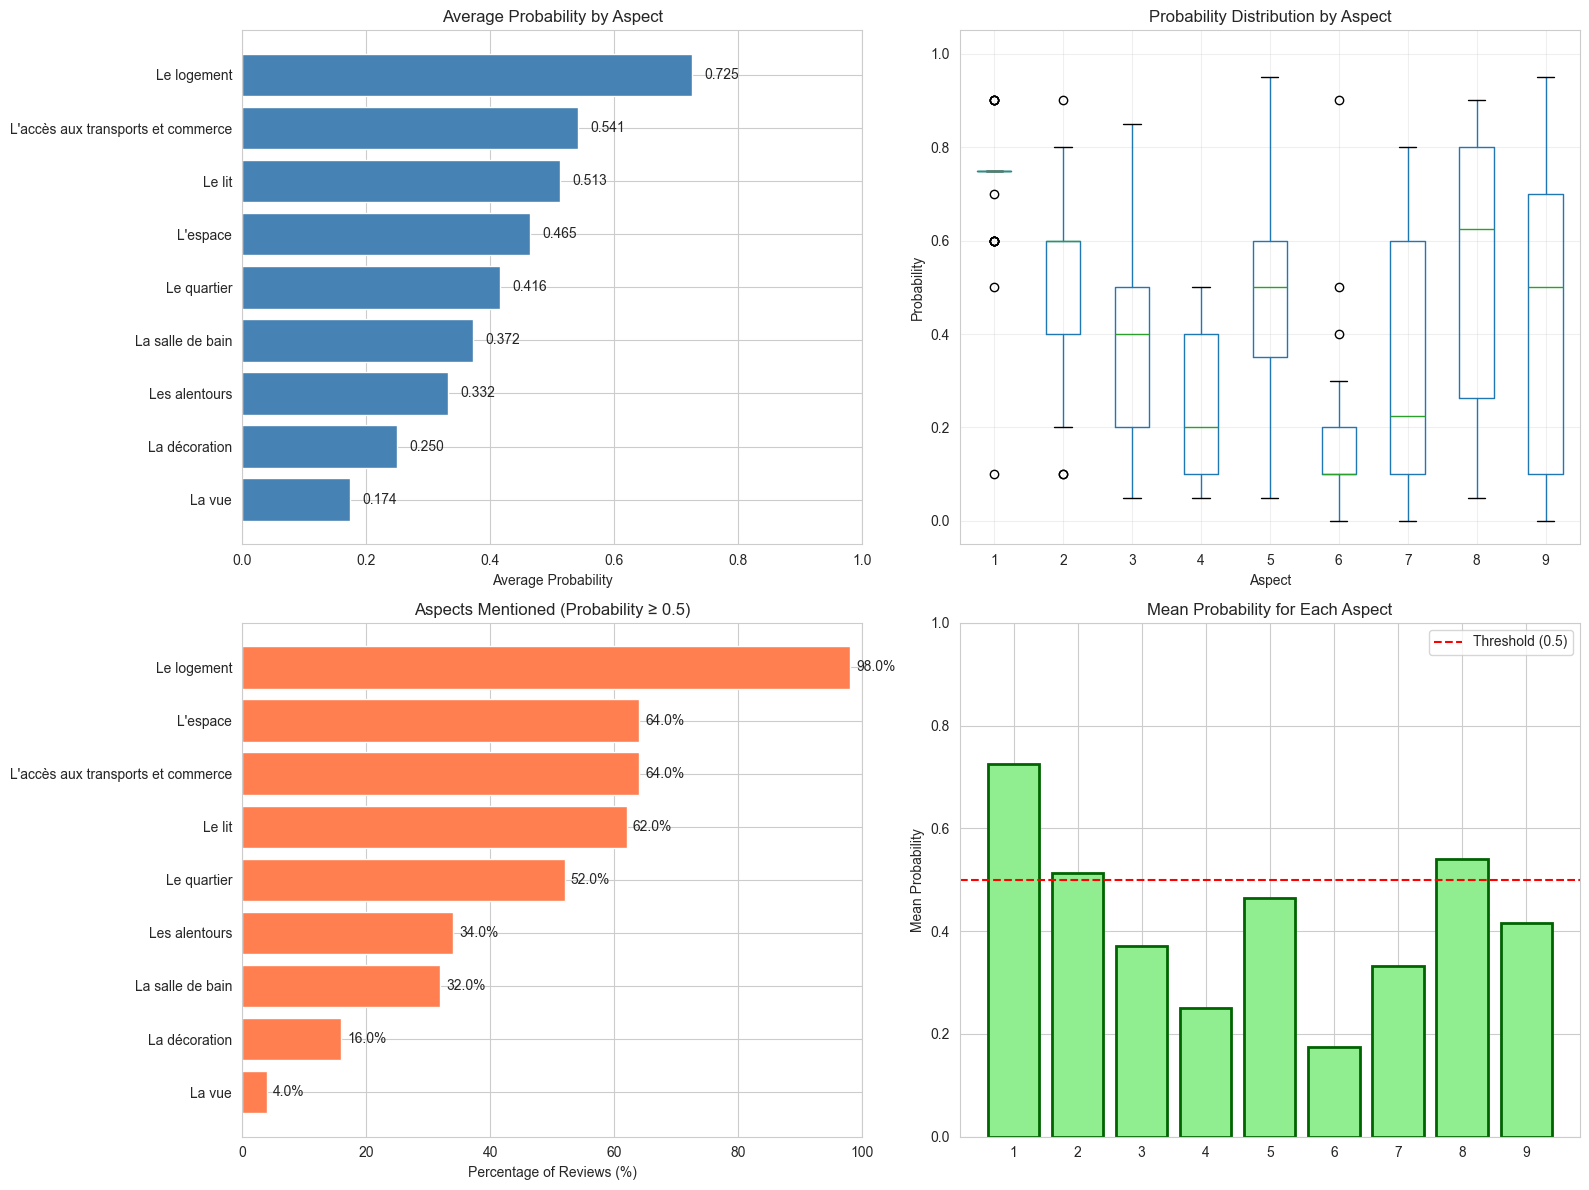

Visualization completed!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average Probability by Aspect (Bar chart)
sorted_stats = stats_df.sort_values('Mean_Probability', ascending=True)
axes[0, 0].barh(sorted_stats['Aspect'], sorted_stats['Mean_Probability'], color='steelblue')
axes[0, 0].set_xlabel('Average Probability')
axes[0, 0].set_title('Average Probability by Aspect')
axes[0, 0].set_xlim(0, 1)

# Add value labels
for i, v in enumerate(sorted_stats['Mean_Probability']):
    axes[0, 0].text(v + 0.02, i, f'{v:.3f}', va='center')

# 2. Box plots for each aspect
prob_cols = [f"prob_{aspect}" for aspect in ASPECTS]
reviews_df[prob_cols].boxplot(ax=axes[0, 1])
axes[0, 1].set_xticklabels([f"{i+1}" for i in range(len(ASPECTS))], rotation=0)
axes[0, 1].set_ylabel('Probability')
axes[0, 1].set_xlabel('Aspect')
axes[0, 1].set_title('Probability Distribution by Aspect')
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].grid(True, alpha=0.3)

# 3. Percentage of reviews with probability >= 0.5
sorted_stats2 = stats_df.sort_values('Percentage_Mentioned', ascending=True)
axes[1, 0].barh(sorted_stats2['Aspect'], sorted_stats2['Percentage_Mentioned'], color='coral')
axes[1, 0].set_xlabel('Percentage of Reviews (%)')
axes[1, 0].set_title('Aspects Mentioned (Probability ≥ 0.5)')
axes[1, 0].set_xlim(0, 100)

# Add value labels
for i, v in enumerate(sorted_stats2['Percentage_Mentioned']):
    axes[1, 0].text(v + 1, i, f'{v:.1f}%', va='center')

# 4. Distribution of mean probabilities
prob_means = [reviews_df[f"prob_{aspect}"].mean() for aspect in ASPECTS]
axes[1, 1].bar(range(len(ASPECTS)), prob_means, color='lightgreen', edgecolor='darkgreen', linewidth=2)
axes[1, 1].set_xticks(range(len(ASPECTS)))
axes[1, 1].set_xticklabels([f"{i+1}" for i in range(len(ASPECTS))], rotation=0)
axes[1, 1].set_ylabel('Mean Probability')
axes[1, 1].set_title('Mean Probability for Each Aspect')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].axhline(y=0.5, color='red', linestyle='--', label='Threshold (0.5)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Visualization completed!")

## 8. Save Results to CSV

In [11]:
# Prepare output dataframe with review and probability columns
output_cols = ['comments'] + [f"prob_{aspect}" for aspect in ASPECTS]
output_df = reviews_df[output_cols].copy()
output_df.columns = ['Review'] + ASPECTS

# Save full results to CSV
results_filename = 'aspect_probability_results.csv'
output_df.to_csv(results_filename, index=False, encoding='utf-8')

print(f"Results saved to: {results_filename}")
print(f"Total records saved: {len(output_df)}")

# Also save probability statistics
stats_df_save = stats_df.copy()
stats_df_save = stats_df_save[['Aspect', 'Mean_Probability', 'Std_Dev', 'Min', 'Max', 'Median', 'Percentage_Mentioned']]
stats_df_save.columns = ['Aspect', 'Mean_Probability', 'Std_Deviation', 'Min_Probability', 'Max_Probability', 'Median_Probability', 'Percentage_Mentioned_50']
stats_filename = 'aspect_probability_statistics.csv'
stats_df_save.to_csv(stats_filename, index=False, encoding='utf-8')

print(f"Statistics saved to: {stats_filename}")

print(f"\nPreview of results (first 5 reviews):")
print(output_df.iloc[:5])

Results saved to: aspect_probability_results.csv
Total records saved: 50
Statistics saved to: aspect_probability_statistics.csv

Preview of results (first 5 reviews):
                                              Review  Le logement  Le lit  \
0  Alloggio confortevole e pratico, dotato di tut...         0.75     0.6   
1  Très bon emplacement pour cet appartement typi...         0.90     0.4   
2  What a wonderful gem.  Great location, it was ...         0.75     0.6   
3  We had a lovely 3 night stay.  Everything was ...         0.75     0.4   
4  Great location. Very calm and quiet. Small but...         0.75     0.6   

   La salle de bain  La décoration  L'espace  La vue  Les alentours  \
0              0.40            0.2       0.5     0.1            0.1   
1              0.20            0.5       0.6     0.3            0.7   
2              0.25            0.4       0.5     0.1            0.2   
3              0.60            0.2       0.5     0.1            0.8   
4              